In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd

In [2]:
import torch


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [ ]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_ch1_ps32_latdim_8_20251002_0445'
output_rootdir = os.path.join(root_dir,'pPax_data_results')
os.makedirs(output_rootdir,exist_ok=True)
czi_base = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568'
analysis_base = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/0311pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/'

ae_path = os.path.join(root_dir,'ae_model_ep9999.pt')
ae = torch.load(ae_path, map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

In [5]:
front_mask_dir = '/mnt/lding/FA/data/FA_ML_Annabel_20250217/pPax_data/eGFP-Zyxin488_Phalloidin405_pPaxy118rb647_PaxM568/frontmasks'

In [6]:
csv_folder = analysis_base + 'ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1159'

csv_filename = 'data_prep_record_9_t9.csv'
group_labels = 0
ctrl_y_str = 'ctrl'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base+ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"



In [7]:
if os.path.isfile(os.path.join(output_rootdir, 'ctrl_latent_array.pkl')):
    print('load files')
    ctrl_latent_array = joblib.load(os.path.join(output_rootdir, 'ctrl_latent_array.pkl'))
    ctrl_patch_label_df = pd.read_csv(os.path.join(output_rootdir, 'ctrl_patch_label_df.csv'))
else:
    print('make the latent and df')
    ctrl_patch_label_df, ctrl_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,ae, device)
    joblib.dump(ctrl_latent_array,os.path.join(output_rootdir, 'ctrl_latent_array.pkl'))
    ctrl_patch_label_df.to_csv(os.path.join(output_rootdir, 'ctrl_patch_label_df.csv'))

load files


In [ ]:
if os.path.isfile(os.path.join(output_rootdir, 'ctrl_latent_array_np_plus6.pkl')):
    print('load files')
    ctrl_latent_array_np_plus6 = joblib.load(os.path.join(output_rootdir, 'ctrl_latent_array_np_plus6.pkl'))
    ctrl_patch_label_df = pd.read_csv(os.path.join(output_rootdir, 'ctrl_patch_label_df.csv'))
    ctrl_all_image_csv = pd.read_csv(os.path.join(output_rootdir, 'ctrl_patch_updated_record.csv'))
else:
    print('make the latent and df')
    ctrl_latent_array_np_plus6, ctrl_patch_label_df, ctrl_all_image_csv = \
        add_features_to_latent(csv_folder,csv_filename,image_folder,ctrl_y_str,cell_mask_folder,front_mask_dir,ctrl_latent_array,ctrl_patch_label_df)
    joblib.dump(ctrl_latent_array_np_plus6,os.path.join(output_rootdir, 'ctrl_latent_array_np_plus6.pkl'))
    ctrl_patch_label_df.to_csv(os.path.join(output_rootdir, 'ctrl_patch_label_df.csv'))
    ctrl_all_image_csv.to_csv(os.path.join(output_rootdir, 'ctrl_patch_updated_record.csv'))


make the latent and df


In [9]:
csv_folder = analysis_base + 'y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_65p_20251125_1139'
csv_filename = 'data_prep_record_10_t10.csv'
group_labels = 1
ctrl_y_str = 'y'
seg_folder_str = 'code_org_20250902_seg'
cell_mask_folder = analysis_base + ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Y-comp'
image_folder = f"{czi_base}/{sub}"




In [10]:
if os.path.isfile(os.path.join(output_rootdir, 'y_latent_array.pkl')):
    print('load Y latent files')
    y_latent_array = joblib.load(os.path.join(output_rootdir, 'y_latent_array.pkl'))
    y_patch_label_df = pd.read_csv(os.path.join(output_rootdir, 'y_patch_label_df.csv'))
else:
    print('make the Y latent and df')
    y_patch_label_df, y_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,ae,device)
    joblib.dump(y_latent_array,os.path.join(output_rootdir, 'y_latent_array.pkl'))
    y_patch_label_df.to_csv(os.path.join(output_rootdir, 'y_patch_label_df.csv'))

load Y latent files


In [11]:
if os.path.isfile(os.path.join(output_rootdir, 'y_latent_array_np_plus6.pkl')):
    print('load files')
    y_latent_array_np_plus6 = joblib.load(os.path.join(output_rootdir, 'y_latent_array_np_plus6.pkl'))
    y_patch_label_df = pd.read_csv(os.path.join(output_rootdir, 'y_patch_label_df.csv'))
    y_all_image_csv = pd.read_csv(os.path.join(output_rootdir, 'y_all_image_csv.csv'))
else:
    print('make the latent and df')
    y_latent_array_np_plus6, y_patch_label_df,y_all_image_csv = \
        add_features_to_latent(csv_folder,csv_filename,image_folder,ctrl_y_str,cell_mask_folder,front_mask_dir,y_latent_array,y_patch_label_df)
    joblib.dump(y_latent_array_np_plus6,os.path.join(output_rootdir, 'y_latent_array_np_plus6.pkl'))
    y_patch_label_df.to_csv(os.path.join(output_rootdir, 'y_patch_label_df.csv'))
    y_all_image_csv.to_csv(os.path.join(output_rootdir, 'y_all_image_csv.csv'))

load files


In [12]:
patch_label_df = pd.concat([ctrl_patch_label_df, y_patch_label_df], ignore_index=True)

latent_array = np.concatenate([ctrl_latent_array_np_plus6, y_latent_array_np_plus6])

print(latent_array.shape)

(5251, 14)


In [13]:
patch_label_df['group_labels']

0       0
1       0
2       0
3       0
4       0
       ..
5246    1
5247    1
5248    1
5249    1
5250    1
Name: group_labels, Length: 5251, dtype: int64

In [14]:
joblib.dump(latent_array,os.path.join(output_rootdir, 'latent_array_plus6_ctrl_y.pkl'))
patch_label_df.to_csv(os.path.join(output_rootdir, 'patch_label_df.csv'))

In [15]:
umap = joblib.load(os.path.join(root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8_UMAP2.pkl.pkl'))

In [16]:
latent_array_np_plus4 = latent_array[:,:12]
latent_array_np_plus4[:,8] = latent_array_np_plus4[:,8]/np.percentile(latent_array_np_plus4[:,8],99)*10
latent_array_np_plus4[:,9] = latent_array_np_plus4[:,9]/np.percentile(latent_array_np_plus4[:,9],99)*10
latent_array_np_plus4[:,10] = latent_array_np_plus4[:,10]/np.percentile(latent_array_np_plus4[:,10],99)*5
latent_array_np_plus4[:,11] = latent_array_np_plus4[:,11]/np.percentile(latent_array_np_plus4[:,11],99)*5

In [17]:
latents_plus4_2d = latent_to_umap(os.path.join(root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8_UMAP2.pkl.pkl'), latent_array_np_plus4)

In [ ]:
# fig = umap_2Dplot(latents_plus3_2d, 0,1,1-patch_label_df['group_labels']+1)

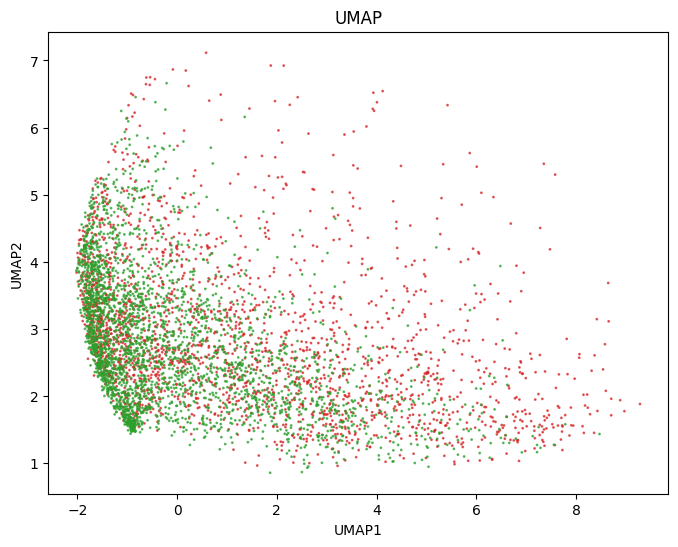

In [41]:
fig = umap_2Dplot(latents_lat8_2d, 0,1,1-patch_label_df['group_labels']+1)

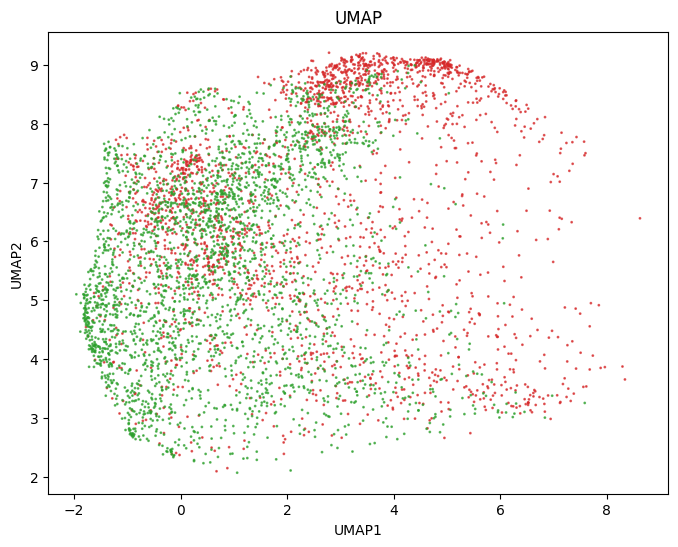

In [20]:
fig = umap_2Dplot(latents_plus4_2d, 0,1,1-patch_label_df['group_labels']+1)

In [21]:
latent_array_np_plus3 = latent_array[:,:11]
latent_array_np_plus3[:,8] = latent_array[:,9]/np.percentile(latent_array[:,9],99)*10
latent_array_np_plus3[:,9] = latent_array[:,10]/np.percentile(latent_array[:,10],99)*5
latent_array_np_plus3[:,10] = latent_array[:,11]/np.percentile(latent_array[:,11],99)*5


In [22]:
latent_array_np_lat8 = latent_array[:,:8]
latents_lat8_2d = latent_to_umap(os.path.join(root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8only_UMAP2.pkl'), latent_array_np_lat8)

In [23]:
# latents_plus3_2d = latent_to_umap(os.path.join(root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8only_UMAP2.pkl'), latent_array_np_plus3)

In [24]:
labelling_csv = pd.read_csv(os.path.join(analysis_base,'project-1-at-2025-12-01-06-21-54a904cb.csv'))

In [25]:
position_label_to_color = {
    "Cell Protruding Edge": 1,
    "Cell Periphery/other": 2,
    "Lamella": 3,
    "Cell Body": 4,
    "No Category/uncertain": 5
}

labelling_csv["position_id"] = labelling_csv["Position"].map(position_label_to_color)

In [26]:
classification_label_to_color = {
    "Nascent Adhesion": 1,
    "focal complex": 2,
    "focal adhesion": 3,
    "fibrillar adhesion": 4,
    "No adhesion": 5,
    "Uncertain":6
}

labelling_csv["FA_type_id"] = labelling_csv["classification"].map(classification_label_to_color)





In [33]:
merged_csv = pd.merge(
    patch_label_df,
    labelling_csv,
    how="inner",
    on="crop_img_filename"
)

In [34]:
merged_csv

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,...,paxillin_patch_image,rand_angle,rand_tx,rand_ty,reference_image,updated_at,vinppax_patch_image,zyxin_patch_image,position_id,FA_type_id
0,0.0,0.0,0,ctrl,ctrl_ch1_f0000x0176y0336ps32.tif,0,2.308008,1.408974,0,0,...,s3://cls-label-bucket/images/task_00000_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00000_full.png,2025-11-26T19:52:43.838402Z,s3://cls-label-bucket/images/task_00000_vinppa...,s3://cls-label-bucket/images/task_00000_zyxin_...,1,1
1,1.0,1.0,1,ctrl,ctrl_ch1_f0000x0176y0368ps32.tif,0,0.625082,3.707923,0,0,...,s3://cls-label-bucket/images/task_00001_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00001_full.png,2025-11-26T19:53:10.371779Z,s3://cls-label-bucket/images/task_00001_vinppa...,s3://cls-label-bucket/images/task_00001_zyxin_...,1,2
2,2.0,2.0,2,ctrl,ctrl_ch1_f0000x0176y0400ps32.tif,0,7.574454,1.265285,0,0,...,s3://cls-label-bucket/images/task_00002_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00002_full.png,2025-11-26T19:53:23.619989Z,s3://cls-label-bucket/images/task_00002_vinppa...,s3://cls-label-bucket/images/task_00002_zyxin_...,1,1
3,3.0,3.0,3,ctrl,ctrl_ch1_f0000x0208y0336ps32.tif,0,7.180059,1.944265,0,0,...,s3://cls-label-bucket/images/task_00003_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00003_full.png,2025-11-26T19:53:37.512426Z,s3://cls-label-bucket/images/task_00003_vinppa...,s3://cls-label-bucket/images/task_00003_zyxin_...,1,1
4,4.0,4.0,4,ctrl,ctrl_ch1_f0000x0208y0368ps32.tif,0,4.072022,2.705921,0,0,...,s3://cls-label-bucket/images/task_00004_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00004_full.png,2025-11-26T19:54:06.115457Z,s3://cls-label-bucket/images/task_00004_vinppa...,s3://cls-label-bucket/images/task_00004_zyxin_...,3,3
5,5.0,5.0,5,ctrl,ctrl_ch1_f0000x0208y0400ps32.tif,0,4.668602,1.402621,0,0,...,s3://cls-label-bucket/images/task_00005_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00005_full.png,2025-11-26T19:54:18.277152Z,s3://cls-label-bucket/images/task_00005_vinppa...,s3://cls-label-bucket/images/task_00005_zyxin_...,3,3
6,6.0,6.0,6,ctrl,ctrl_ch1_f0000x0208y0432ps32.tif,0,7.104533,2.551773,0,0,...,s3://cls-label-bucket/images/task_00006_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00006_full.png,2025-11-26T19:54:48.810022Z,s3://cls-label-bucket/images/task_00006_vinppa...,s3://cls-label-bucket/images/task_00006_zyxin_...,1,1
7,7.0,7.0,7,ctrl,ctrl_ch1_f0000x0240y0336ps32.tif,0,4.423479,2.588407,0,0,...,s3://cls-label-bucket/images/task_00007_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00007_full.png,2025-11-26T20:04:50.193548Z,s3://cls-label-bucket/images/task_00007_vinppa...,s3://cls-label-bucket/images/task_00007_zyxin_...,2,3
8,8.0,8.0,8,ctrl,ctrl_ch1_f0000x0240y0368ps32.tif,0,1.432552,2.793554,0,0,...,s3://cls-label-bucket/images/task_00008_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00008_full.png,2025-11-26T20:05:09.699471Z,s3://cls-label-bucket/images/task_00008_vinppa...,s3://cls-label-bucket/images/task_00008_zyxin_...,3,6
9,9.0,9.0,9,ctrl,ctrl_ch1_f0000x0240y0400ps32.tif,0,4.800074,1.350639,0,0,...,s3://cls-label-bucket/images/task_00009_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00009_full.png,2025-11-26T20:05:19.737723Z,s3://cls-label-bucket/images/task_00009_vinppa...,s3://cls-label-bucket/images/task_00009_zyxin_...,3,5


In [35]:
position_label_to_color = {
    "Cell Protruding Edge": 1,
    "Cell Periphery/other": 2,
    "Lamella": 3,
    "Cell Body": 4,
    "No Category/uncertain": 5
}


In [36]:
merged_csv

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,...,paxillin_patch_image,rand_angle,rand_tx,rand_ty,reference_image,updated_at,vinppax_patch_image,zyxin_patch_image,position_id,FA_type_id
0,0.0,0.0,0,ctrl,ctrl_ch1_f0000x0176y0336ps32.tif,0,2.308008,1.408974,0,0,...,s3://cls-label-bucket/images/task_00000_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00000_full.png,2025-11-26T19:52:43.838402Z,s3://cls-label-bucket/images/task_00000_vinppa...,s3://cls-label-bucket/images/task_00000_zyxin_...,1,1
1,1.0,1.0,1,ctrl,ctrl_ch1_f0000x0176y0368ps32.tif,0,0.625082,3.707923,0,0,...,s3://cls-label-bucket/images/task_00001_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00001_full.png,2025-11-26T19:53:10.371779Z,s3://cls-label-bucket/images/task_00001_vinppa...,s3://cls-label-bucket/images/task_00001_zyxin_...,1,2
2,2.0,2.0,2,ctrl,ctrl_ch1_f0000x0176y0400ps32.tif,0,7.574454,1.265285,0,0,...,s3://cls-label-bucket/images/task_00002_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00002_full.png,2025-11-26T19:53:23.619989Z,s3://cls-label-bucket/images/task_00002_vinppa...,s3://cls-label-bucket/images/task_00002_zyxin_...,1,1
3,3.0,3.0,3,ctrl,ctrl_ch1_f0000x0208y0336ps32.tif,0,7.180059,1.944265,0,0,...,s3://cls-label-bucket/images/task_00003_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00003_full.png,2025-11-26T19:53:37.512426Z,s3://cls-label-bucket/images/task_00003_vinppa...,s3://cls-label-bucket/images/task_00003_zyxin_...,1,1
4,4.0,4.0,4,ctrl,ctrl_ch1_f0000x0208y0368ps32.tif,0,4.072022,2.705921,0,0,...,s3://cls-label-bucket/images/task_00004_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00004_full.png,2025-11-26T19:54:06.115457Z,s3://cls-label-bucket/images/task_00004_vinppa...,s3://cls-label-bucket/images/task_00004_zyxin_...,3,3
5,5.0,5.0,5,ctrl,ctrl_ch1_f0000x0208y0400ps32.tif,0,4.668602,1.402621,0,0,...,s3://cls-label-bucket/images/task_00005_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00005_full.png,2025-11-26T19:54:18.277152Z,s3://cls-label-bucket/images/task_00005_vinppa...,s3://cls-label-bucket/images/task_00005_zyxin_...,3,3
6,6.0,6.0,6,ctrl,ctrl_ch1_f0000x0208y0432ps32.tif,0,7.104533,2.551773,0,0,...,s3://cls-label-bucket/images/task_00006_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00006_full.png,2025-11-26T19:54:48.810022Z,s3://cls-label-bucket/images/task_00006_vinppa...,s3://cls-label-bucket/images/task_00006_zyxin_...,1,1
7,7.0,7.0,7,ctrl,ctrl_ch1_f0000x0240y0336ps32.tif,0,4.423479,2.588407,0,0,...,s3://cls-label-bucket/images/task_00007_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00007_full.png,2025-11-26T20:04:50.193548Z,s3://cls-label-bucket/images/task_00007_vinppa...,s3://cls-label-bucket/images/task_00007_zyxin_...,2,3
8,8.0,8.0,8,ctrl,ctrl_ch1_f0000x0240y0368ps32.tif,0,1.432552,2.793554,0,0,...,s3://cls-label-bucket/images/task_00008_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00008_full.png,2025-11-26T20:05:09.699471Z,s3://cls-label-bucket/images/task_00008_vinppa...,s3://cls-label-bucket/images/task_00008_zyxin_...,3,6
9,9.0,9.0,9,ctrl,ctrl_ch1_f0000x0240y0400ps32.tif,0,4.800074,1.350639,0,0,...,s3://cls-label-bucket/images/task_00009_paxill...,0.0,0.0,0.0,s3://cls-label-bucket/images/task_00009_full.png,2025-11-26T20:05:19.737723Z,s3://cls-label-bucket/images/task_00009_vinppa...,s3://cls-label-bucket/images/task_00009_zyxin_...,3,5


Text(0.5, 1.0, 'UMAP')

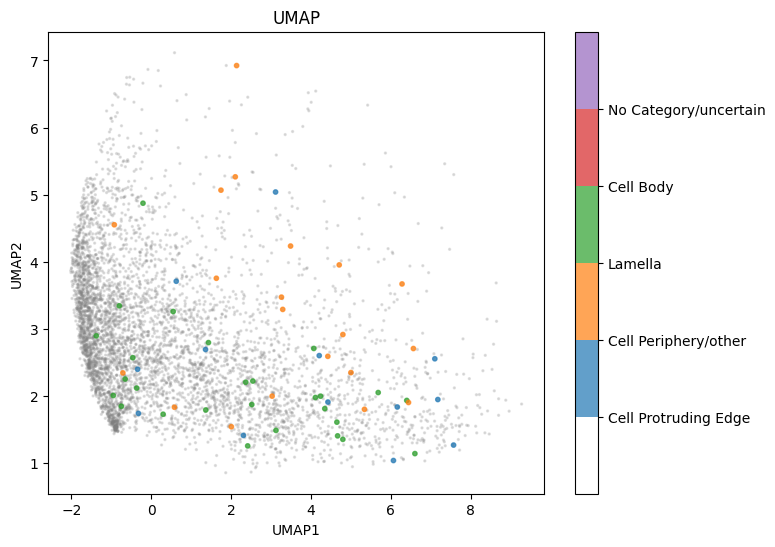

In [37]:
import matplotlib.pyplot as plt
# fig = umap_2Dplot(latents_plus3_2d, 0,1,5-patch_label_df['group_labels']*0+1)
fig = plt.figure(figsize=(8, 6))
plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  
plt.scatter(merged_csv['UMAP_d0'] , merged_csv['UMAP_d1'] , c=merged_csv['position_id'], cmap='tab10', alpha=0.7, s=10, vmin=1, vmax=11)

cbar = plt.colorbar()
cbar.set_ticks(list(position_label_to_color.values()))
cbar.set_ticklabels(list(position_label_to_color.keys()))
cbar.ax.set_ylim(0, 6)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP") 

Text(0.5, 1.0, 'UMAP')

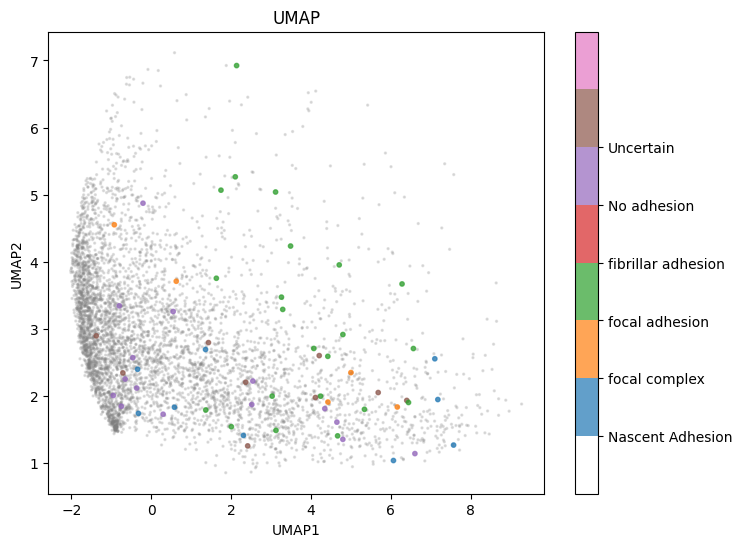

In [38]:
import matplotlib.pyplot as plt
# fig = umap_2Dplot(latents_plus3_2d, 0,1,5-patch_label_df['group_labels']*0+1)
fig = plt.figure(figsize=(8, 6))
plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  
plt.scatter(merged_csv['UMAP_d0'] , merged_csv['UMAP_d1'] , c=merged_csv['FA_type_id'], cmap='tab10', alpha=0.7, s=10, vmin=1, vmax=11)

cbar = plt.colorbar()
cbar.set_ticks(list(classification_label_to_color.values()))
cbar.set_ticklabels(list(classification_label_to_color.keys()))
cbar.ax.set_ylim(0, 8)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP") 

In [39]:
pgroup_label_to_color = {
    "Control": 3,
    "Y": 2
}

Text(0.5, 1.0, 'UMAP')

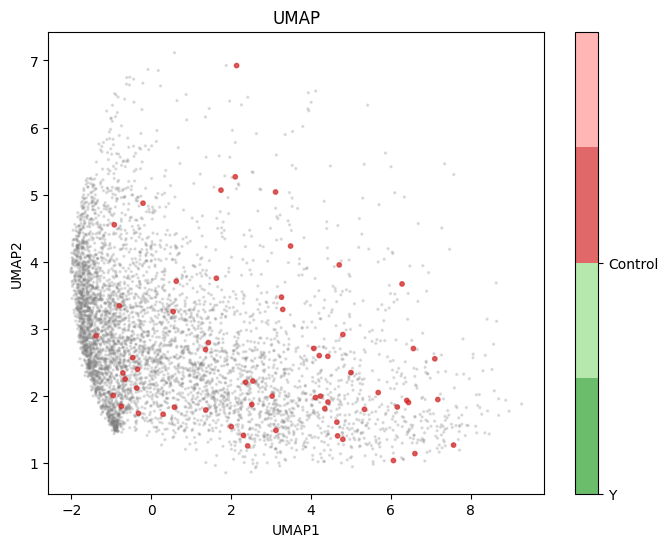

In [40]:
import matplotlib.pyplot as plt
# fig = umap_2Dplot(latents_plus3_2d, 0,1,5-patch_label_df['group_labels']*0+1)
fig = plt.figure(figsize=(8, 6))
plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  
plt.scatter(merged_csv['UMAP_d0'] , merged_csv['UMAP_d1'] , c=1-merged_csv['group_labels']+2, cmap='tab20', alpha=0.7, s=10, vmin=0, vmax=10)

cbar = plt.colorbar()
cbar.set_ticks(list(pgroup_label_to_color.values()))
cbar.set_ticklabels(list(pgroup_label_to_color.keys()))
cbar.ax.set_ylim(2, 4)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP") 

In [32]:
patch_label_df['UMAP_d0'] = latents_lat8_2d[:,0]
patch_label_df['UMAP_d1'] = latents_lat8_2d[:,1]

NameError: name 'plt' is not defined

In [ ]:
merged_csv.columns


Index(['Unnamed: 0.1', 'Unnamed: 0', 'ctrl_y_str', 'crop_img_filename',
       'group_labels', 'UMAP_d0', 'UMAP_d1', 'DBSCAN_labels', 'kmeans_labels',
       'vinculin_intensity', 'pax_intensity', 'actin_intensity',
       'dist_cell_edge', 'front_flag', 'Position', 'actin_patch_image',
       'annotation_id', 'annotator', 'bbox_x1', 'bbox_x2', 'bbox_y1',
       'bbox_y2', 'classification', 'created_at', 'csv_row_index',
       'czi_filename', 'filename_id', 'id', 'image', 'lead_time',
       'original_x_c', 'original_y_c', 'patch_center_x', 'patch_center_y',
       'paxillin_patch_image', 'rand_angle', 'rand_tx', 'rand_ty',
       'reference_image', 'updated_at', 'vinppax_patch_image',
       'zyxin_patch_image', 'position_id', 'FA_type_id'],
      dtype='object')